# Análise Financeira — Custos de Pessoal
### Budget vs Forecast | FP&A Case Study

**Objetivo do projeto:** simular o acompanhamento mensal de custos de pessoal de uma
empresa (folha, encargos e benefícios para 1.134 funcionários) e identificar,
quantificar e explicar os principais desvios entre o que foi orçado e o que
efetivamente aconteceu (ou está projetado a acontecer).

Este é o tipo de análise que uma área de FP&A (Financial Planning & Analysis) faz
todo mês para o CFO: **não basta mostrar o número, é preciso explicar o motivo
do desvio e recomendar uma ação.**

Estrutura deste notebook:
1. Geração dos dados (dados sintéticos, mas com lógica de negócio real)
2. Visão macro: Budget x Realizado/Forecast mês a mês
3. Onde estão os maiores desvios (Top 10 contas)
4. Impacto percentual por grupo de contas
5. Tendência dos desvios ao longo do ano
6. Distribuição estatística dos desvios
7. Conclusões e recomendações
8. Exportação do relatório em Excel (com fórmulas nativas)


In [ ]:
import sys
sys.path.append('..')

import pandas as pd
from src.data_generator import gerar_dre, Premissas
from src.analysis import (
    comparativo_mensal, top_desvios, impacto_por_grupo,
    tendencia_mensal, kpis_executivos,
)
from src.visualizations import (
    plot_comparativo_mensal, plot_top_desvios, plot_impacto_por_grupo,
    plot_tendencia_mensal, plot_distribuicao_desvio,
)

pd.options.display.float_format = 'R$ {:,.2f}'.format


## 1. Geração dos dados

Os dados são sintéticos (não há uma empresa real por trás), mas a lógica de geração reproduz regras reais de folha de pagamento brasileira: FGTS (8%), INSS patronal (20%), rateio de VR/VA por dias úteis, sazonalidade de férias e 13º salário, e efeito de admissões/demissões no headcount mês a mês. Os 7 primeiros meses são tratados como **Realizado** (com ruído aleatório simulando o comportamento real vs. o planejado) e os últimos 5 como **Forecast**. A coluna `Cenário` do DataFrame indica, para cada mês, se a 2ª coluna representa Realizado ou Forecast.

In [ ]:
premissas = Premissas()
df = gerar_dre(premissas)

print(f"Linhas: {len(df)} | Período: {df['Mês'].min()} a {df['Mês'].max()}")
print(df.drop_duplicates('Mês')[['Mês', 'Cenário']].to_string(index=False))
df.head()

Linhas: 180 | Período: 01-Jan a 12-Dez
   Mês   Cenário
01-Jan Realizado
02-Fev Realizado
03-Mar Realizado
04-Abr Realizado
05-Mai Realizado
06-Jun Realizado
07-Jul Realizado
08-Ago Projetado
09-Set Projetado
10-Out Projetado
11-Nov Projetado
12-Dez Projetado


,Mês,Cenário,Grupo,Conta,Budget,Forecast,Diferença,Diferença_%
0,01-Jan,Realizado,0331 - Salários e afins,033101 - Salários e ordenados,"R$ -2,249,856.00","R$ -2,197,867.09","R$ 51,988.91",R$ 2.31
1,01-Jan,Realizado,0331 - Salários e afins,033102 - Férias,"R$ -184,000.00","R$ -186,059.52","R$ -2,059.52",R$ -1.12
2,01-Jan,Realizado,0331 - Salários e afins,033103 - 13º salário,R$ 0.00,R$ 0.00,R$ 0.00,R$ 0.00
3,01-Jan,Realizado,0331 - Salários e afins,033104 - Rescisões,"R$ -45,000.00","R$ -57,003.27","R$ -12,003.27",R$ -26.67
4,01-Jan,Realizado,0331 - Salários e afins,033105 - Hora extra,"R$ -70,000.00","R$ -69,187.54",R$ 812.46,R$ 1.16


## 2. Visão macro: Budget vs. Realizado/Forecast mês a mês

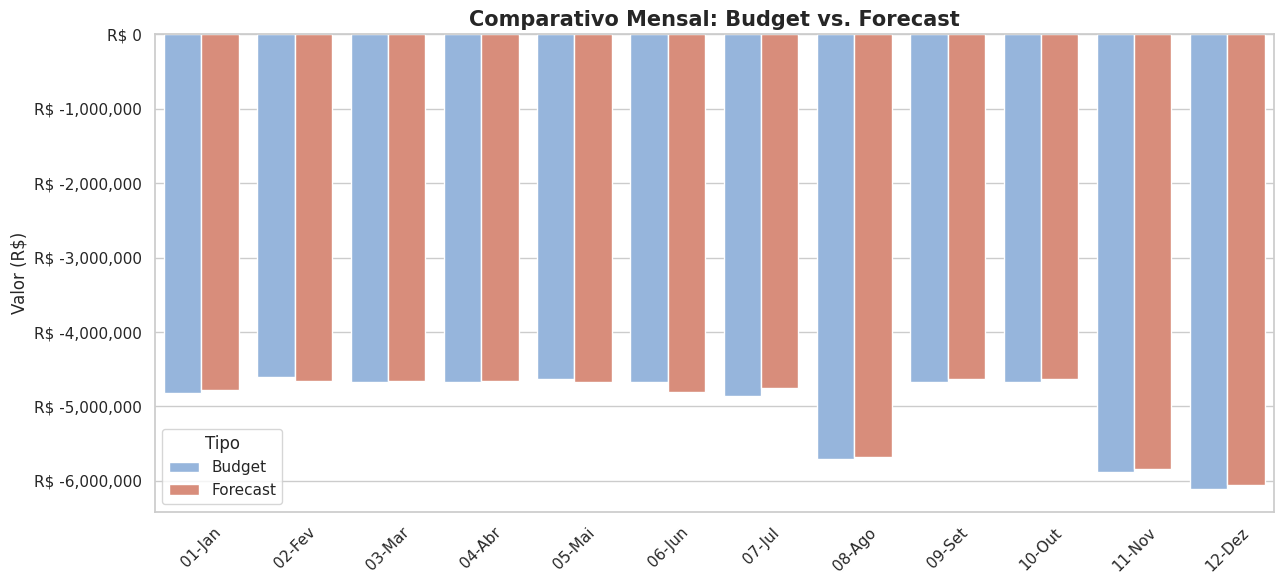

In [ ]:
df_comp = comparativo_mensal(df)
fig = plot_comparativo_mensal(df_comp)

**Leitura do gráfico:** no acumulado do ano (Realizado + Forecast juntos), o
Budget totaliza **R$ -60.008.622,16** e o Forecast Ano **R$ -59.826.297,39** — uma economia de **R$ 182.324,77 (+0,30%)** em relação ao orçado. Mas olhando **só para
os 7 meses já Realizados**, o desvio é de **-R$ 36.951,23**, ou seja, a
empresa gastou *mais* do que o orçado nos meses que já fecharam (um estouro
pequeno, de 0,11%). O excedente do ano inteiro vem do **Forecast** dos meses
futuros, que já carrega o headcount atual (maior que o inicial) — é uma
projeção, não um fato ainda. Essa distinção importa: se você reportasse só o
número anual consolidado, esconderia que os meses **já fechados** ainda
estão levemente **acima** do orçado, e que a economia do ano inteiro depende
do que ainda está projetado para Ago-Dez, não do que já aconteceu.

## 3. Onde estão os maiores desvios (Top 10 contas)

,Grupo,Conta,Budget_Total,Forecast_Total,Diferenca_Total
0,0331 - Salários e afins,033101 - Salários e ordenados,"R$ -26,998,272.00","R$ -26,724,456.09","R$ 273,815.91"
1,0331 - Salários e afins,033104 - Rescisões,"R$ -540,000.00","R$ -778,430.09","R$ -238,430.09"
2,0334 - Benefícios,033401 - VR/VA,"R$ -10,359,090.00","R$ -10,299,450.00","R$ 59,640.00"
3,0332 - Encargos trabalhistas,033201 - FGTS,"R$ -2,159,861.76","R$ -2,137,798.17","R$ 22,063.59"
4,0331 - Salários e afins,033103 - 13º salário,"R$ -2,494,800.00","R$ -2,472,800.00","R$ 22,000.00"
5,0334 - Benefícios,033402 - Cesta básica,"R$ -3,402,000.00","R$ -3,381,750.00","R$ 20,250.00"
6,0332 - Encargos trabalhistas,033202 - INSS,"R$ -5,399,654.40","R$ -5,387,565.91","R$ 12,088.49"
7,0334 - Benefícios,033406 - Vale transporte,"R$ -1,374,408.00","R$ -1,366,855.43","R$ 7,552.57"
8,0334 - Benefícios,033407 - Bônus/PPR,"R$ -1,375,000.00","R$ -1,378,087.61","R$ -3,087.61"
9,0331 - Salários e afins,033105 - Hora extra,"R$ -840,000.00","R$ -837,103.48","R$ 2,896.52"


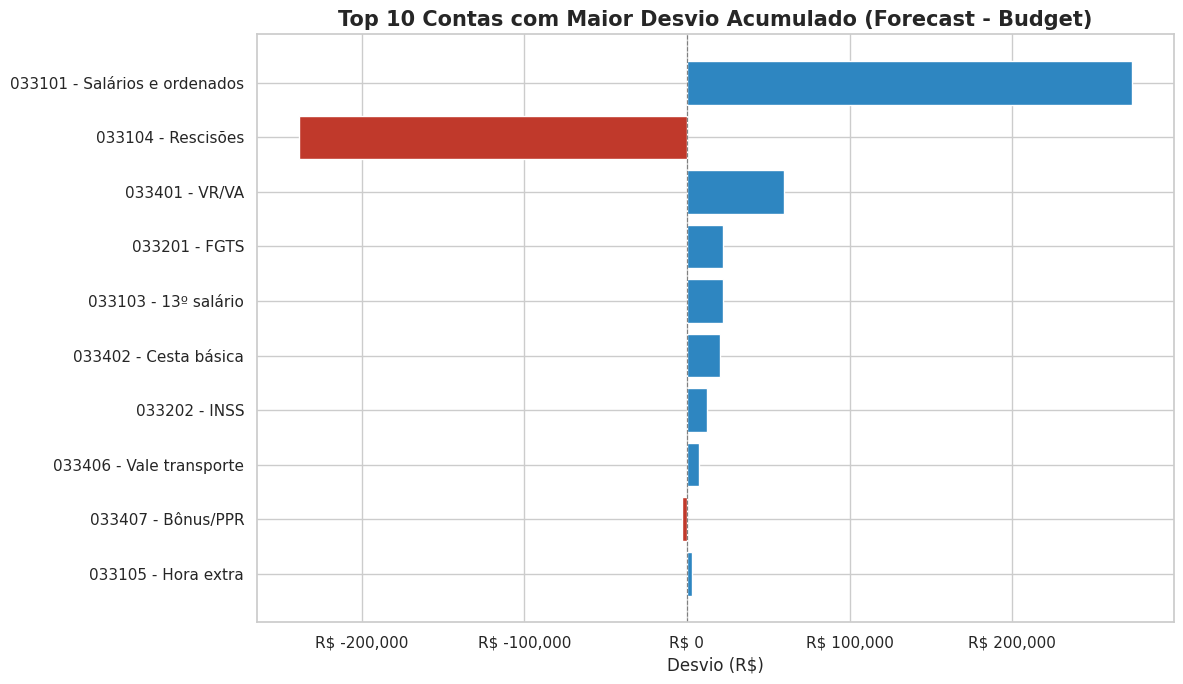

In [ ]:
df_top = top_desvios(df, n=10)
fig = plot_top_desvios(df_top, n=10)
df_top[['Grupo', 'Conta', 'Budget_Total', 'Forecast_Total', 'Diferenca_Total']]

**Leitura:** as duas maiores movimentações do ano são opostas e quase se
cancelam — e, ao investigar a tendência mensal, ambas apontam para o
**mesmo evento**: um lote de demissões concentrado em Junho.
- **Salários e ordenados** ficou **R$ 273.815,91 abaixo** do orçado
  (economia) — o desligamento de pessoas em Junho reduziu o quadro para
  abaixo do que o Budget previa, e essa base menor de headcount se
  propaga como economia de folha para o Forecast dos meses seguintes.
- **Rescisões** ficou **R$ 238.430,09 acima** do orçado (estouro) — o
  mesmo lote de demissões gerou um pico de custo de rescisão em Junho
  (R$ 146,7 mil realizados contra R$ 45 mil orçados só naquele mês), que
  a empresa não havia provisionado.

Isso é um padrão clássico de DRE de pessoal: duas contas diferentes
contam a mesma história de negócio (o desligamento de pessoas), mas com
sinais opostos, estouro imediato em Rescisões, economia futura em
Salários. Olhando só o total elas quase se cancelam e escondem essa
causa comum.

## 4. Percentual por grupo de contas

,Grupo,Budget_Total,Forecast_Total,Diferenca_Total,Impacto_%
0,0332 - Encargos trabalhistas,"R$ -7,559,516.16","R$ -7,525,364.08","R$ 34,152.08",R$ 0.45
1,0334 - Benefícios,"R$ -20,484,034.00","R$ -20,397,814.64","R$ 86,219.36",R$ 0.42
2,0331 - Salários e afins,"R$ -31,965,072.00","R$ -31,903,118.67","R$ 61,953.33",R$ 0.19


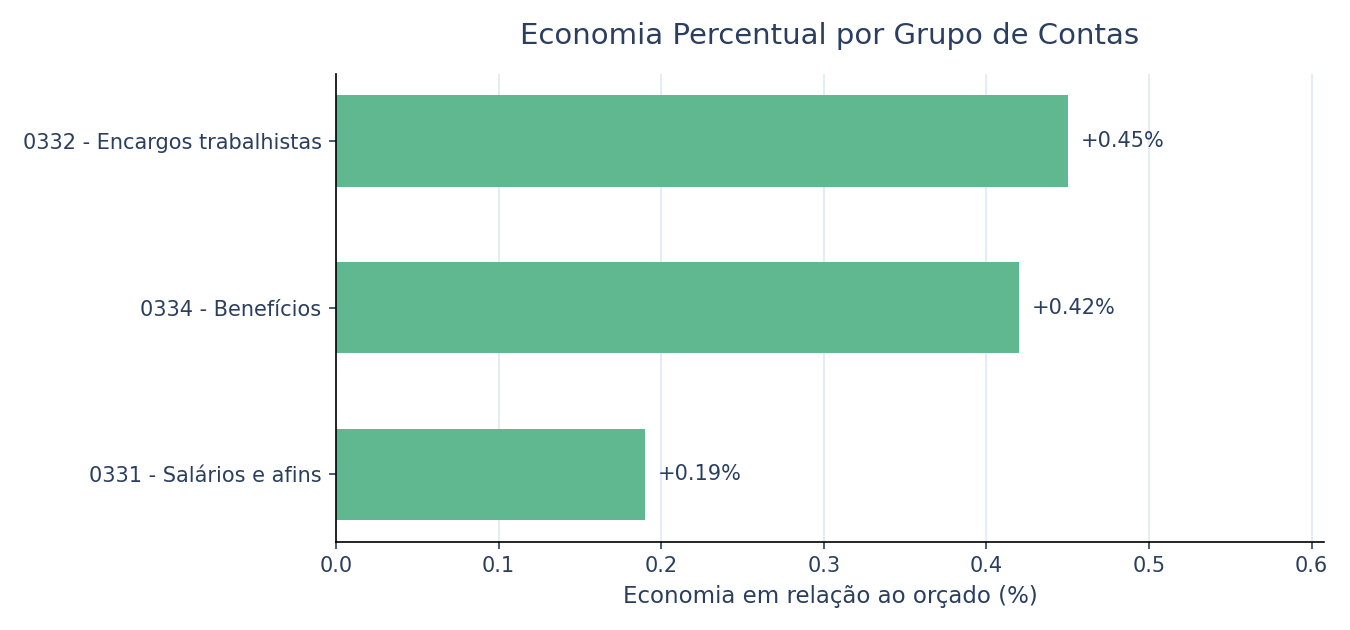

In [ ]:
df_impacto = impacto_por_grupo(df)
fig = plot_impacto_por_grupo(df_impacto)
df_impacto

**Leitura:** os três grupos tiveram **economia** em relação ao orçado — nenhum teve estouro. Em termos percentuais, **Encargos Trabalhistas** é o grupo proporcionalmente com a **maior economia** (+0,45%), seguido de perto por **Benefícios** (+0,42%) e depois **Salários e afins** (+0,19%). Isso faz sentido: encargos (FGTS/INSS) são calculados como percentual da folha, então a economia de Salários (puxada pela redução de headcount em Junho) se propaga automaticamente para eles.

## 5. Tendência mensal dos desvios (contas mais críticas)

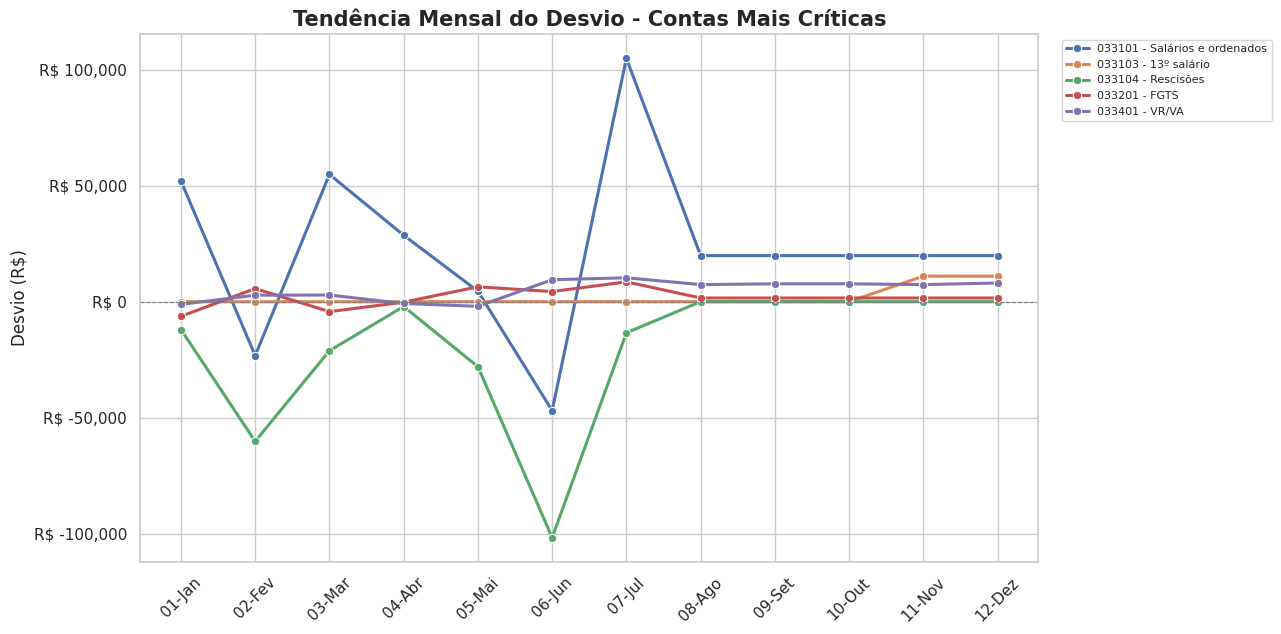

In [ ]:
top5_contas = df_top.head(5)['Conta'].tolist()
df_tend = tendencia_mensal(df, top5_contas)
fig = plot_tendencia_mensal(df_tend)

**Leitura:** o gráfico de tendência mostra se um desvio é pontual (um mês
fora da curva) ou estrutural (persiste mês a mês). Desvios estruturais são
os que merecem revisão do próprio orçamento para o próximo ciclo; desvios
pontuais geralmente têm uma causa isolada (ex.: um lote de rescisões
concentrado em um mês específico). Vale notar que, a partir de Agosto, a
linha passa a refletir Forecast — ou seja, tendência projetada, não mais
fato observado.

## 6. Distribuição estatística dos desvios por grupo

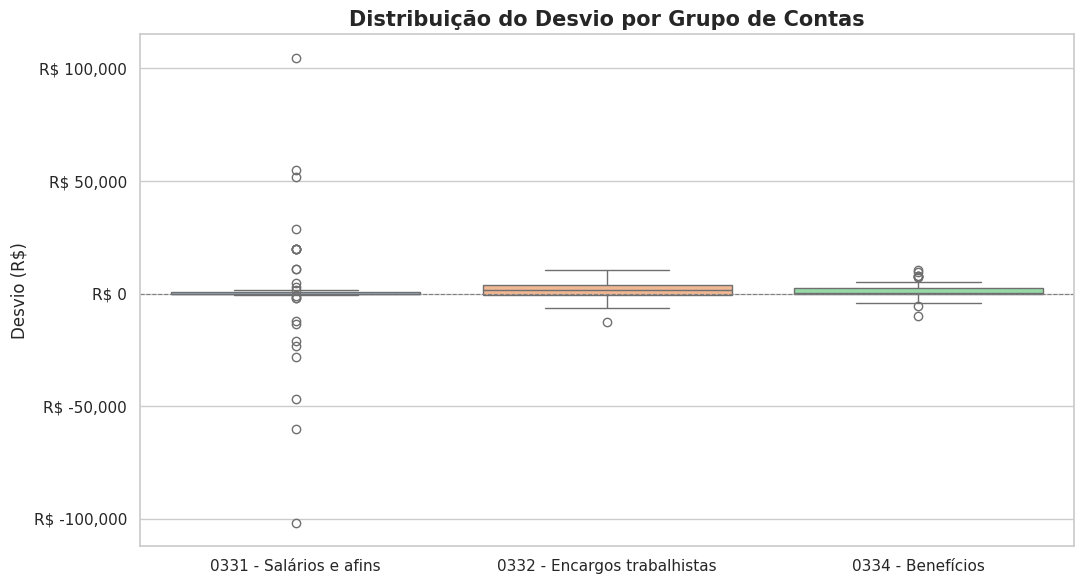

In [ ]:
fig = plot_distribuicao_desvio(df)

**Leitura:** o boxplot evidencia a **dispersão** de cada grupo, não só a
média. 'Salários e afins' tem a maior variabilidade — esperado, já que reúne
contas com dinâmicas muito diferentes entre si (salário fixo, hora extra,
rescisão, férias). Grupos com caixa mais estreita, como Encargos, têm
comportamento mais previsível.

## 7. Conclusões e recomendações

- Nos meses **já Realizados** (Jan–Jul), a folha ficou **acima** do
  orçado (+R$ 36,9 mil, um estouro de 0,11%) — desvio pequeno, dentro da
  margem normal de ruído mês a mês, mas ainda assim **acima** do plano,
  não uma economia.
- O **Forecast** mostra uma economia de **+0,30%** sobre o orçado — mas
  esse número só existe porque embute as despesas de Ago-Dez, que ainda
  não fecharam. Se os meses futuros não se confirmarem como projetado,
  essa economia pode não se realizar.
- O maior risco identificado não é o valor agregado, mas a **compensação
  parcial entre contas**: as demissões de Junho geraram **R$ 273,8 mil**
  de economia em Salários e **R$ 238,4 mil** de estouro em Rescisões. A
  soma líquida ainda é positiva (**+R$ 35,4 mil**), mas as duas contas
  **não se cancelam por completo**. Vale acompanhar de perto: se novos
  desligamentos elevarem o estouro em Rescisões sem uma economia
  proporcional em Salários, essa conta pode sair do controle.
- Recomenda-se acompanhar **Encargos Trabalhistas em conjunto com Salários**,
  já que o desvio de um se propaga automaticamente para o outro.

## 8. Exportação do relatório em Excel

O relatório completo (com fórmulas nativas, não valores fixos) é exportado
em `outputs/DRE_Comparativa_Mensal.xlsx`, com duas abas:
- `DRE_Mensal`: visão gerencial por Grupo/Conta, mês a mês, com subtotais e
  Total Geral calculados por fórmula. O cabeçalho de cada mês muda de cor
  e de rótulo (Realizado em azul, Forecast em dourado) para deixar a
  fronteira entre fato e projeção visualmente óbvia.
- `Dados_Brutos`: base tidy, pronta para o usuário montar sua própria tabela
  dinâmica.


In [ ]:
from src.excel_export import exportar_dre_excel

caminho = exportar_dre_excel(df, premissas.estrutura_dre, '../outputs/DRE_Comparativa_Mensal.xlsx')
print(f"Relatório exportado para: {caminho}")


Relatório exportado para: ../outputs/DRE_Comparativa_Mensal.xlsx
